# HealthConnect Clinic: No-Show Prediction
### Week 4 Data Science Track: Problem Understanding and Initial Assessment
### AnalystLab Africa Experience Lab

**Prepared by:** Data Science Intern
**Project:** HealthConnect Clinic Experience Lab
**Track:** Data Science

This notebook covers the Week 4 Data Science deliverable for the HealthConnect project. The goal this week isn't to build a model. It's to understand the problem properly, check whether the data can actually support a no-show prediction solution, and lay out a plan before touching any modelling code.

Sections covered:
1. Problem definition
2. Initial data assessment
3. Proposed target variable and how cancellations are treated
4. Potential input features
5. Initial modelling approach
6. Key modelling considerations, risks and assumptions
7. Summary and next steps for Week 5

## 1. Problem Definition

HealthConnect Clinic loses appointment slots every time a patient books a slot and simply doesn't turn up. Aside from the wasted clinic capacity, no-shows also mean the patient themselves goes without care they may have needed, and other patients on a waiting list lose the chance to take that slot.

From a data science point of view, this is a binary classification problem: given what we know about a patient and their appointment at the time it's booked (or shortly before it happens), can we estimate how likely they are to not show up?

If the clinic can flag high-risk appointments in advance, they could act on it in a few ways: send an extra reminder, call the patient directly, double-book a slot that's very likely to be missed, or offer an earlier or more convenient time. None of that requires the model to be perfect. Even a model that's moderately better than guessing gives the clinic something to act on that they don't have today.

**Central question for this track:** Can the HealthConnect appointment data support a model that predicts, at or before booking time, whether a scheduled appointment will end up as a no-show?

## 2. Initial Data Assessment

We start by loading the dataset and the data dictionary and getting a feel for what's actually in it before deciding anything about features or modelling.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)

df = pd.read_csv('HealthConnect_Appointment_Data.csv')
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")
df.head()

Rows: 5000, Columns: 18


,appointment_id,patient_id,gender,age,age_group,appointment_type,booking_date,appointment_date,appointment_day,appointment_time,booking_lead_days,previous_appointments,previous_no_shows,reminder_sent,reminder_channel,distance_to_clinic_km,waiting_time_minutes,appointment_outcome
0,HC-00001,P-1613,Female,39,35-44,Follow-up,2/6/2025,2/18/2025,Tuesday,Afternoon,12,2,0,Yes,WhatsApp,19.3,29.0,No-Show
1,HC-00002,P-0813,Male,31,25-34,Specialist Consultation,2/25/2026,2/27/2026,Friday,Morning,2,6,0,Yes,SMS,14.3,42.0,Attended
2,HC-00003,P-1366,Female,50,45-54,General Consultation,11/16/2025,12/24/2025,Wednesday,Morning,38,5,1,Yes,SMS,11.4,11.0,No-Show
3,HC-00004,P-1031,Male,59,55-64,Follow-up,7/18/2025,8/28/2025,Thursday,Evening,41,3,1,Yes,SMS,7.4,35.0,Attended
4,HC-00005,P-1458,Female,34,25-34,Follow-up,7/9/2025,8/25/2025,Monday,Afternoon,47,3,1,Yes,Email,5.6,27.0,No-Show


### 2.1 Data types and structure

Checking the dtypes against what the data dictionary says they should be. Dates are read in as text by default, so those need converting before they're useful.

In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   appointment_id         5000 non-null   str    
 1   patient_id             5000 non-null   str    
 2   gender                 5000 non-null   str    
 3   age                    5000 non-null   int64  
 4   age_group              5000 non-null   str    
 5   appointment_type       5000 non-null   str    
 6   booking_date           5000 non-null   str    
 7   appointment_date       5000 non-null   str    
 8   appointment_day        5000 non-null   str    
 9   appointment_time       5000 non-null   str    
 10  booking_lead_days      5000 non-null   int64  
 11  previous_appointments  5000 non-null   int64  
 12  previous_no_shows      5000 non-null   int64  
 13  reminder_sent          5000 non-null   str    
 14  reminder_channel       3634 non-null   str    
 15  distance_to_cli

In [3]:
df['booking_date'] = pd.to_datetime(df['booking_date'])
df['appointment_date'] = pd.to_datetime(df['appointment_date'])
df[['booking_date', 'appointment_date']].describe()

,booking_date,appointment_date
count,5000,5000
mean,2025-08-31 03:01:09.120000,2025-09-29 18:20:44.160000
min,2024-11-07 00:00:00,2025-01-01 00:00:00
25%,2025-04-15 00:00:00,2025-05-15 00:00:00
50%,2025-08-28 00:00:00,2025-09-27 00:00:00
75%,2026-01-16 06:00:00,2026-02-15 00:00:00
max,2026-06-27 00:00:00,2026-06-30 00:00:00


### 2.2 Missing values

The data dictionary flags `reminder_channel`, `distance_to_clinic_km` and `waiting_time_minutes` as having some missing values, so let's confirm that and see if the pattern makes sense.

In [4]:
missing = df.isnull().sum()
missing = missing[missing > 0]
missing_pct = (missing / len(df) * 100).round(1)
pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})

,missing_count,missing_pct
reminder_channel,1366,27.3
distance_to_clinic_km,90,1.8
waiting_time_minutes,60,1.2


`reminder_channel` is the biggest gap. Worth checking whether it's actually missing at random or whether it's simply blank whenever no reminder was sent in the first place, since that would make it not a data quality problem at all.

In [5]:
pd.crosstab(df['reminder_sent'], df['reminder_channel'].isnull(), rownames=['reminder_sent'], colnames=['reminder_channel_missing'])

reminder_channel_missing,False,True
reminder_sent,,
No,0,1366
Yes,3634,0


That confirms it: every single row where `reminder_channel` is missing is a row where `reminder_sent` is "No". So this isn't messy data, it's a structural gap: there's no channel to record when nothing was sent. This can be filled in with a label like "None" rather than treated as missing at random.

`distance_to_clinic_km` (90 missing) and `waiting_time_minutes` (60 missing) don't have an obvious explanation like that from the columns available, so those look like genuine gaps that will need a simple imputation strategy (median fill, most likely) or a "missing" flag if the missingness itself turns out to matter.

### 2.3 Duplicates and ID integrity

In [6]:
print("Duplicate appointment_id values:", df['appointment_id'].duplicated().sum())
print("Duplicate full rows:", df.duplicated().sum())
print("Unique patients:", df['patient_id'].nunique(), "across", len(df), "appointments")

Duplicate appointment_id values: 0
Duplicate full rows: 0
Unique patients: 1696 across 5000 appointments


No duplicate appointment IDs and no duplicate rows, so the dataset looks clean on that front. Patients do appear more than once (fewer unique patient IDs than rows), which matters later: if we ever split into train and test sets, we should make sure the same patient doesn't end up in both, otherwise the model could effectively memorise a patient's history instead of generalising.

### 2.4 Logical consistency checks

A couple of sanity checks the data dictionary hints at: `previous_no_shows` shouldn't exceed `previous_appointments`, and `booking_lead_days` shouldn't be negative (you can't book an appointment after it already happened).

In [7]:
bad_noshow = (df['previous_no_shows'] > df['previous_appointments']).sum()
bad_lead = (df['booking_lead_days'] < 0).sum()
print("Rows where previous_no_shows > previous_appointments:", bad_noshow)
print("Rows with negative booking_lead_days:", bad_lead)

Rows where previous_no_shows > previous_appointments: 0
Rows with negative booking_lead_days: 0


Both checks come back clean. Good sign that this dataset, even though it's synthetic, was generated with some care around internal consistency.

### 2.5 Target column: appointment_outcome

In [8]:
outcome_counts = df['appointment_outcome'].value_counts()
outcome_pct = (outcome_counts / len(df) * 100).round(1)
pd.DataFrame({'count': outcome_counts, 'pct': outcome_pct})

,count,pct
appointment_outcome,,
No-Show,2423,48.5
Attended,2314,46.3
Cancelled,263,5.3


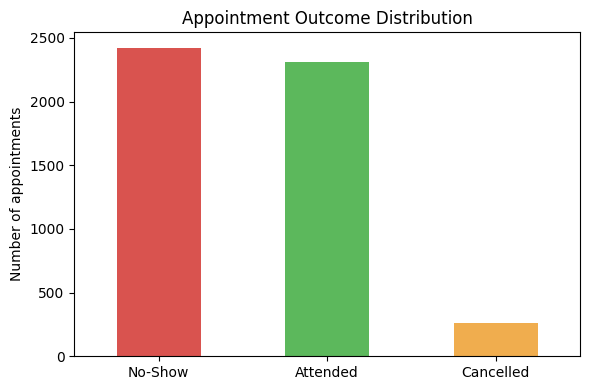

In [9]:
fig, ax = plt.subplots(figsize=(6, 4))
outcome_counts.plot(kind='bar', ax=ax, color=['#d9534f', '#5cb85c', '#f0ad4e'])
ax.set_title('Appointment Outcome Distribution')
ax.set_ylabel('Number of appointments')
ax.set_xlabel('')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

No-shows and attended appointments are roughly balanced (about 48% and 46% of all appointments), with cancellations making up a much smaller slice at around 5%. That near 50/50 split between the two main outcomes is actually a nice starting point: a lot of real-world no-show datasets are heavily skewed toward attendance, which makes modelling harder. Here we won't be fighting severe class imbalance, at least not once cancellations are set aside.

## 3. Proposed Target Variable

**Target variable:** a binary column, `is_no_show`, defined as:

- 1 if `appointment_outcome` is "No-Show"
- 0 if `appointment_outcome` is "Attended"

### Handling cancellations

Cancelled appointments are a genuinely different situation from a no-show. A cancellation means the patient told the clinic in advance they weren't coming, which is exactly the outcome the clinic wants more of, whereas a no-show gives no warning at all. Lumping the two together as "didn't attend" would blur two different behaviours and two different intervention strategies (a cancelled slot can often be reused; a no-show slot usually can't).

For this first pass, the cleanest approach is to **exclude cancelled appointments from model training entirely** and frame the problem strictly as "no-show vs attended, given the appointment happened as scheduled or was missed without notice." Cancellations are worth analysing separately later, possibly as their own prediction task, but they shouldn't be forced into the no-show target.

In [10]:
df_model = df[df['appointment_outcome'] != 'Cancelled'].copy()
df_model['is_no_show'] = (df_model['appointment_outcome'] == 'No-Show').astype(int)

print(f"Rows available for modelling (cancellations excluded): {len(df_model)}")
print(f"No-show rate in modelling set: {df_model['is_no_show'].mean():.1%}")

Rows available for modelling (cancellations excluded): 4737


No-show rate in modelling set: 51.2%


After removing cancellations, the no-show rate sits at just over 51%. That's a well-balanced target, which is a genuinely useful starting condition for a first model.

## 4. Potential Input Features

Going column by column through what's available, grouped by what kind of signal they might carry.

**Patient and demographic features**
- `age` / `age_group`: worth testing both the raw number and the banded version
- `gender`

**Appointment-level features**
- `appointment_type`: general consultation, follow-up, specialist consultation, diagnostic test
- `appointment_day`: day of week
- `appointment_time`: morning, afternoon, evening
- `booking_lead_days`: how far in advance the appointment was booked

**Patient history features**
- `previous_appointments`: how many appointments this patient has had before
- `previous_no_shows`: how many of those were missed

**Reminder features**
- `reminder_sent`: yes or no
- `reminder_channel`: SMS, WhatsApp, email, or none

**Logistics features**
- `distance_to_clinic_km`
- `waiting_time_minutes`: flagged below as one to think carefully about

A quick look at how the no-show rate moves across a few of these will help decide which ones are worth prioritising.

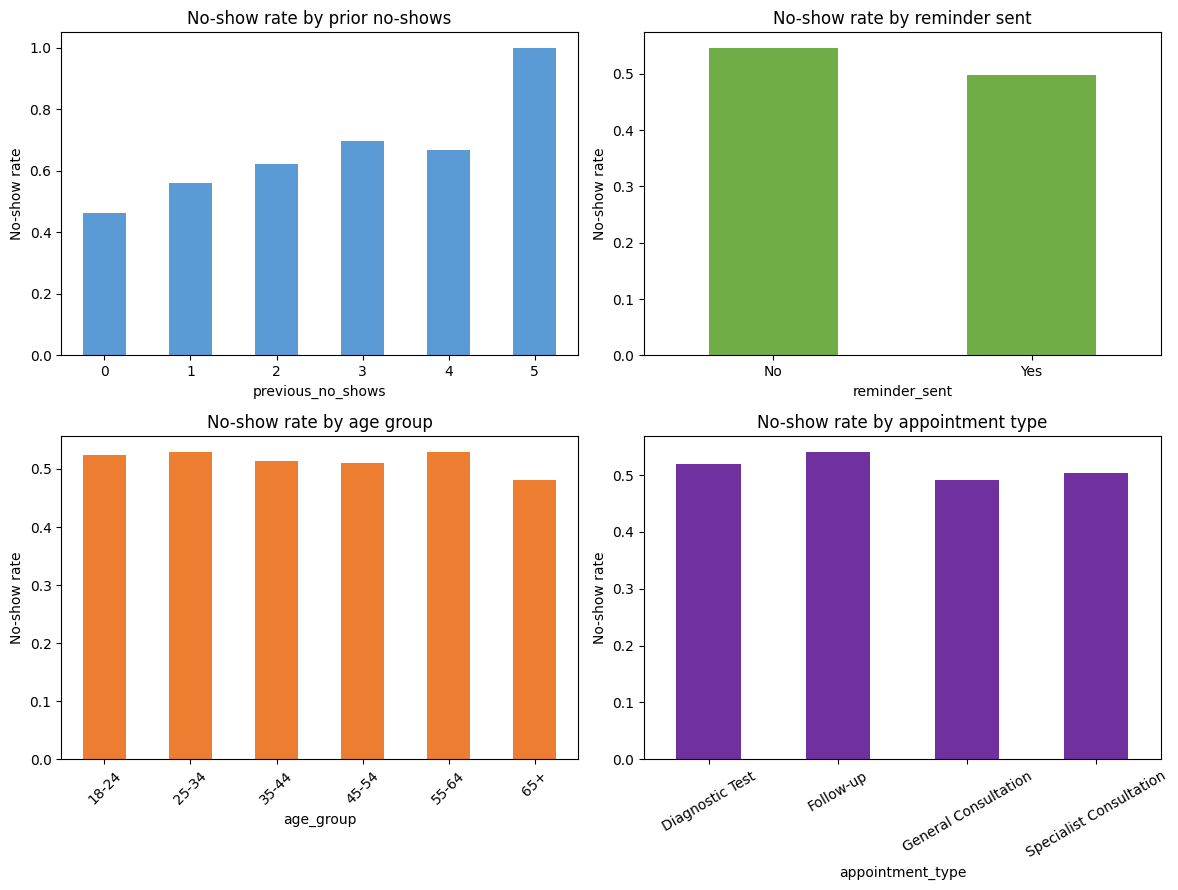

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

df_model.groupby('previous_no_shows')['is_no_show'].mean().plot(
    kind='bar', ax=axes[0, 0], color='#5b9bd5'
)
axes[0, 0].set_title('No-show rate by prior no-shows')
axes[0, 0].set_ylabel('No-show rate')
axes[0, 0].tick_params(axis='x', rotation=0)

df_model.groupby('reminder_sent')['is_no_show'].mean().plot(
    kind='bar', ax=axes[0, 1], color='#70ad47'
)
axes[0, 1].set_title('No-show rate by reminder sent')
axes[0, 1].set_ylabel('No-show rate')
axes[0, 1].tick_params(axis='x', rotation=0)

df_model.groupby('age_group')['is_no_show'].mean().sort_index().plot(
    kind='bar', ax=axes[1, 0], color='#ed7d31'
)
axes[1, 0].set_title('No-show rate by age group')
axes[1, 0].set_ylabel('No-show rate')
axes[1, 0].tick_params(axis='x', rotation=45)

df_model.groupby('appointment_type')['is_no_show'].mean().plot(
    kind='bar', ax=axes[1, 1], color='#7030a0'
)
axes[1, 1].set_title('No-show rate by appointment type')
axes[1, 1].set_ylabel('No-show rate')
axes[1, 1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

`previous_no_shows` shows the clearest pattern by far: patients with zero prior no-shows sit around 46%, and that climbs steadily to nearly 70% for patients with three or more. That's the single strongest signal found so far, and it makes intuitive sense: past behaviour tends to predict future behaviour.

Reminders show a small effect in the expected direction (sent reminders correlate with slightly fewer no-shows), but it's a modest difference, not a dramatic one. Age group and appointment type show only mild variation, which suggests they'll add a little value but won't carry a model on their own.

A quick correlation check on the numeric features backs this up.

In [12]:
numeric_cols = ['booking_lead_days', 'previous_appointments', 'previous_no_shows',
                 'distance_to_clinic_km', 'waiting_time_minutes']
df_model[numeric_cols + ['is_no_show']].corr()['is_no_show'].sort_values(ascending=False)

is_no_show               1.000000
booking_lead_days        0.287255
previous_no_shows        0.122892
distance_to_clinic_km    0.065213
previous_appointments    0.042421
waiting_time_minutes    -0.004062
Name: is_no_show, dtype: float64

`booking_lead_days` and `previous_no_shows` stand out as the two numeric features most related to the target. Distance and waiting time show only a weak relationship on their own, though they might still combine usefully with other features once we get to actual modelling.

**A feature to flag now: `waiting_time_minutes`.** This is recorded as part of the appointment record, which raises a question of timing. If it's the *actual* waiting time on the day, that's only known after the appointment has already happened, which means it can't be used to predict a no-show before the appointment. That would be data leakage: using information from the future to predict something that's already decided. This needs a definitive answer from whoever owns the data before it goes anywhere near a model. Until then, it's treated as excluded from the feature set by default.

## 5. Initial Modelling Approach

Nothing here is final. This is a plan for how to approach modelling once Week 4 planning is done, not a model that's been built yet.

1. **Baseline first.** Before any machine learning, establish a simple baseline: what accuracy would predicting "always attended" or "always no-show" give, and what does a simple rule like "flag anyone with 2 or more previous no-shows" achieve on its own. Any real model needs to clearly beat this.
2. **Start simple.** A logistic regression as the first real model, since it's easy to interpret and gives the clinic a sense of which factors actually move the needle, before trying anything more complex.
3. **Try a tree-based model next.** Something like Random Forest or Gradient Boosting to check whether it picks up interactions between features that logistic regression would miss (for example, whether the effect of a reminder differs by appointment type).
4. **Split by patient, not just by row.** Because the same patient can appear multiple times, the train/test split should be done at the patient level to avoid the same patient's history leaking across both sets.
5. **Compare against the baseline honestly**, using metrics that make sense for a roughly balanced binary target: accuracy, precision, recall, and F1, with recall on the no-show class given real weight since missing a likely no-show is the costly type of error for the clinic.

This is intentionally a plan, not a build. Week 4 is about confirming the data supports the idea and mapping out how to approach it responsibly.

## 6. Key Modelling Considerations, Assumptions, Limitations and Risks

**Assumptions**
- The dataset is described as synthetic and anonymised. It's assumed to be representative enough of real appointment patterns to be useful for building and testing an approach, even though it isn't real patient data.
- `previous_no_shows` and `previous_appointments` are assumed to be counted only up to (not including) the current appointment, so they reflect genuinely prior history rather than accidentally including the outcome being predicted.

**Data limitations**
- No information here on why a patient didn't show up (transport issues, feeling better, forgetting, cost, etc). The model can predict *that* someone is likely to miss an appointment, not *why*, which limits how targeted an intervention can be.
- Missing values in `distance_to_clinic_km` and `waiting_time_minutes` need a documented, consistent handling strategy rather than being dropped, since dropping ninety-plus rows for one column and its own further sixty for another starts to add up.

**Risk of data leakage**
- `waiting_time_minutes` needs its timing clarified before use, as covered above.
- `appointment_outcome` and anything derived from it obviously can't be used as a feature; this is worth stating explicitly since it's an easy mistake to make when a column sits right next to the target in the data.

**Ethical considerations**
- A no-show prediction model touches demographic and location data (age, gender, distance from clinic). If any of these end up strongly predictive, the clinic should think about how predictions get used: flagging a patient as high-risk should lead to more support and better reminders, not a change in the quality or availability of care they're offered.
- Because this uses historical patterns, it's worth checking the model doesn't unfairly concentrate "high-risk" labels on any particular group in a way that leads to worse treatment for that group.

**Project dependencies**
- Depends on the Data Analytics track's initial data quality work not conflicting with what's found here; worth comparing notes.
- Any cleaned or imputed version of the dataset should be saved separately from the original file, per the project resource instructions, and the changes documented so the reasoning is traceable later.

## 7. Week 4 Summary and Week 5 Focus

**Problem this track addresses:** whether HealthConnect's appointment data can support a model that predicts, ahead of time, which appointments are at risk of becoming a no-show.

**Resources used:** `HealthConnect_Appointment_Data.csv` (5,000 appointment records) and the `HealthConnect_Data_Dictionary` to confirm variable definitions.

**Key observations:**
- The data is structurally clean: no duplicate IDs, no logical inconsistencies between related columns, and the target classes are close to balanced once cancellations are set aside.
- `previous_no_shows` is the strongest signal found so far, followed by `booking_lead_days`. Reminder status has a smaller but sensible effect.
- Missing values are limited to three columns and one of them (`reminder_channel`) has a fully explainable pattern rather than being random.
- `waiting_time_minutes` needs a timing clarification before it can safely be used as a feature.

**Proposed approach:** treat this as a binary classification problem (no-show vs attended), exclude cancellations from the target, start with a baseline and logistic regression, then test a tree-based model, splitting by patient to avoid leakage.

**Focus for Week 5:** clean and impute the flagged columns, engineer the age and history-based features discussed here, build the baseline and first logistic regression model, and get an initial read on performance against the baseline.